In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error

In [2]:
# a single neuron = logistic regression

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

X = np.array([
    [1.0, 2.0],
    [-1.0, 1.0],
    [0.5, -2.0]
])
w = np.array([0.8, -0.4])
b = 0.2

print(X @ w + b)
print(sigmoid(X @ w + b))

[ 0.2 -1.   1.4]
[0.549834   0.26894142 0.80218389]


w = [ 7.11692396 -3.73294391]  b = 1.2500071626294038


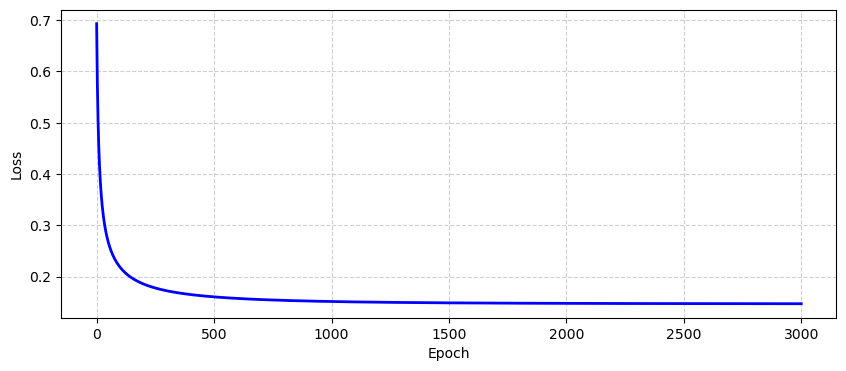

In [38]:
# fit p_i = sigmoid(x_i * w + b) by gradient descent

rng = np.random.default_rng(1)

n = 700
X = rng.normal(size=(n, 2))
y = (2 * X[:, 0] - X[:, 1] + 0.3 + rng.normal(size=n, scale=0.5) > 0).astype(float)

def L(p):   # cross-entropy
    return - np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

w = [0, 0]
b = 0
lr = 0.3    # learning rate
epochs = 3000
loss = []

for _ in range(epochs):
    p = sigmoid(X @ w + b)
    loss.append(L(p))
    w -= lr * (X.T @ (p - y)) / n
    b -= lr * np.mean(p - y)

print("w =", w, " b =", b)

plt.figure(figsize=(10, 4))
plt.plot(loss, color="blue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

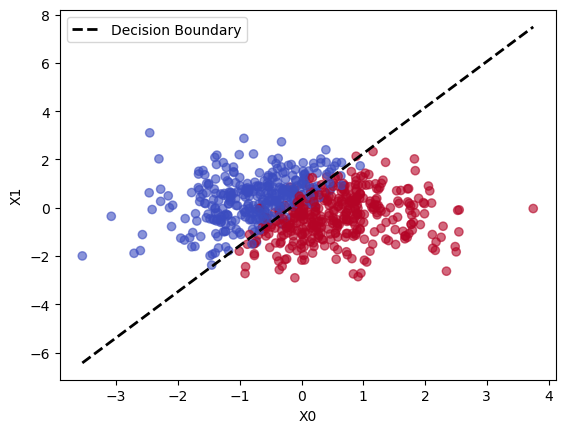

In [43]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)

x0 = np.array([X[:, 0].min(), X[:, 0].max()])
plt.plot(x0, -(w[0] * x0 + b) / w[1], "k--", lw=2, label="Decision Boundary")

plt.xlabel("X0")
plt.ylabel("X1")
plt.legend()
plt.show()

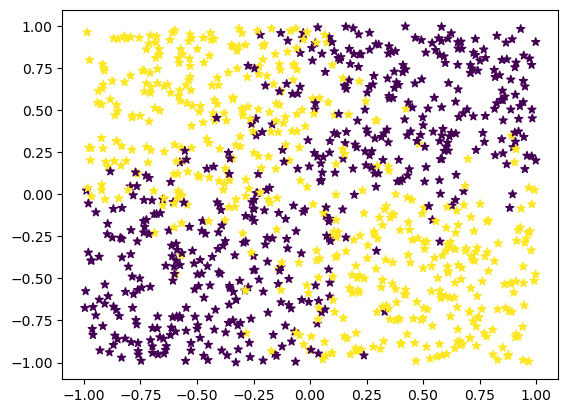

In [103]:
# XOR data (non-linear decision boundary)

rng = np.random.default_rng(1)

n = 1000
X = rng.uniform(-1, 1, size=(n, 2))
y = ((X[:, 0] > rng.normal(size=n, scale=0.2)) \
     != (X[:, 1] > rng.normal(size=n, scale=0.2))).astype(float)

plt.scatter(X[:, 0], X[:, 1], marker="*", c=y)

In [106]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x):
        return self.network(x)
    
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32
)
y_test_tensor = torch.tensor(
    y_test.reshape(-1, 1),
    dtype=torch.float32
)

model = XORNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

for epoch in range(1000):
    optimizer.zero_grad()
    loss = criterion(model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer.step()

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    prob = torch.sigmoid(test_logits)
    pred = (prob >= 0.5).float()
    accuracy = (pred == y_test_tensor).float().mean()

print("test accuracy =", accuracy.item())

test accuracy = 0.7833333611488342
